In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_excel("KINGSDATA.xlsx")
df

,King/Queen,Dynasty,Region,State,Period,Battle,Battle Type,Strategy,Outcome,Army_Size,Estimated_Casualties,Loot_Impact,Conversion_Impact
0,Chandragupta Maurya,Maurya,North India,Bihar,321-297 BCE,Nanda Dynasty,Offensive,Expansion,Victory,25795,3869,Medium,High
1,Ashoka,Maurya,Pan India,Odisha,268-232 BCE,Kalinga War,Offensive,Direct,Victory,10860,1629,Low,High
2,Samudragupta,Gupta,North India,UP,335-375 CE,Campaigns,Offensive,Expansion,Victory,86820,13023,High,High
3,Harsha,Vardhana,North India,Haryana,606-647 CE,Regional wars,Defensive,Alliance,Victory,64886,9732,High,High
4,Pulakeshin II,Chalukya,Deccan,Karnataka,610-642 CE,Harsha,Defensive,Defense,Victory,16265,2439,Medium,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,Tipu Sultan,Mysore,South,Karnataka,1782-1799 CE,British,Defensive,Rocket,Martyr,36854,14741,Medium,High
108,Ranjit Singh,Sikh,North,Punjab,1801-1839 CE,Afghans,Defensive,Modern army,Victory,74505,11175,Medium,Low
109,Alluri Sitarama Raju,Tribal,South,AP,1920s,British,Guerrilla,Forest,Martyr,62251,24900,Low,Low
110,Sam Manekshaw,India,Modern,India,1971,Pakistan,Offensive,Strategy,Victory,32662,4899,Medium,Medium


In [2]:
df.isnull()

,King/Queen,Dynasty,Region,State,Period,Battle,Battle Type,Strategy,Outcome,Army_Size,Estimated_Casualties,Loot_Impact,Conversion_Impact
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,False,False,False,False,False,False,False,False,False,False,False,False,False
108,False,False,False,False,False,False,False,False,False,False,False,False,False
109,False,False,False,False,False,False,False,False,False,False,False,False,False
110,False,False,False,False,False,False,False,False,False,False,False,False,False


In [18]:
if df.isnull().values.any(): 
    print("Null values present")
else:
    print("No null values")

No null values


In [4]:
"""legend_info=df.columns[["King/Queen","Dynasty","Battle"]]
legend_info
.columns works with number values"""

'legend_info=df.columns[["King/Queen","Dynasty","Battle"]]\nlegend_info\n.columns works with number values'

In [5]:
legend_info=df[["King/Queen","Dynasty","Battle"]]
legend_info

,King/Queen,Dynasty,Battle
0,Chandragupta Maurya,Maurya,Nanda Dynasty
1,Ashoka,Maurya,Kalinga War
2,Samudragupta,Gupta,Campaigns
3,Harsha,Vardhana,Regional wars
4,Pulakeshin II,Chalukya,Harsha
...,...,...,...
107,Tipu Sultan,Mysore,British
108,Ranjit Singh,Sikh,Afghans
109,Alluri Sitarama Raju,Tribal,British
110,Sam Manekshaw,India,Pakistan


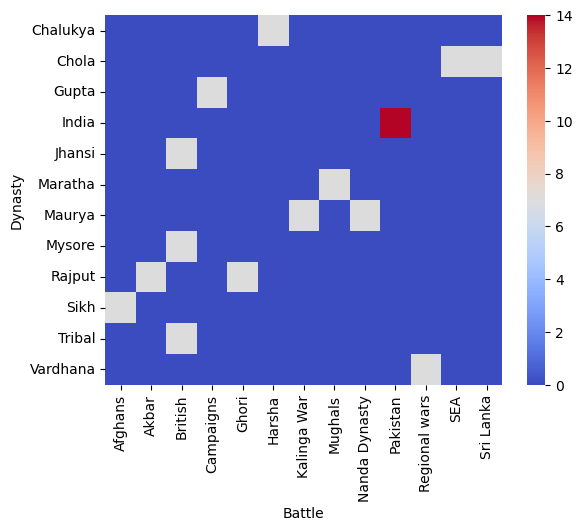

In [6]:
#similar battles fought by different dynasties
cross_tab = pd.crosstab(legend_info["Dynasty"], legend_info["Battle"])
sns.heatmap(cross_tab, cmap="coolwarm")
plt.show()

In [7]:

victories = df[df["Outcome"] == "Victory"]

victories = victories.drop_duplicates(subset=["King/Queen"])
print(victories)

             King/Queen   Dynasty       Region        State        Period  \
0   Chandragupta Maurya    Maurya  North India        Bihar   321-297 BCE   
1                Ashoka    Maurya    Pan India       Odisha   268-232 BCE   
2          Samudragupta     Gupta  North India           UP    335-375 CE   
3                Harsha  Vardhana  North India      Haryana    606-647 CE   
4         Pulakeshin II  Chalukya       Deccan    Karnataka    610-642 CE   
5       Raja Raja Chola     Chola        South   Tamil Nadu   985-1014 CE   
6        Rajendra Chola     Chola        South   Tamil Nadu  1014-1044 CE   
9       Shivaji Maharaj   Maratha         West  Maharashtra  1674-1680 CE   
12         Ranjit Singh      Sikh        North       Punjab  1801-1839 CE   
14        Sam Manekshaw     India       Modern        India          1971   
15         Vikram Batra     India       Modern           HP          1999   

           Battle Battle Type       Strategy  Outcome  Army_Size  \
0   Nan

In [8]:
print(df.columns)

Index(['King/Queen', 'Dynasty', 'Region', 'State', 'Period', 'Battle',
       'Battle Type', 'Strategy', 'Outcome', 'Army_Size',
       'Estimated_Casualties', 'Loot_Impact', 'Conversion_Impact'],
      dtype='object')


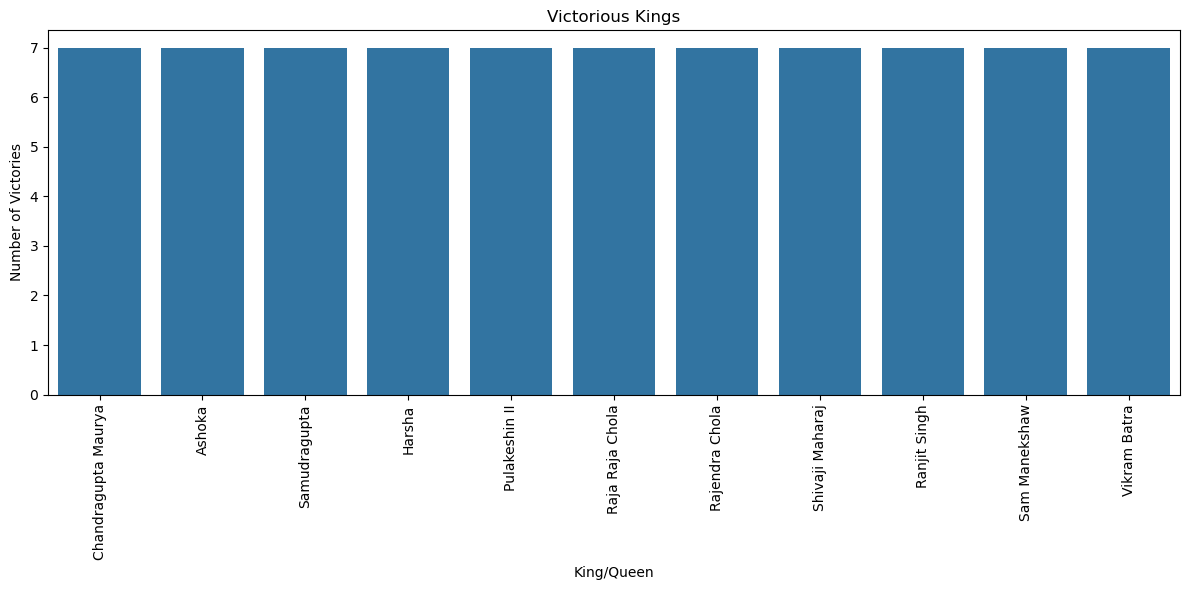

In [9]:
'''import matplotlib.pyplot as plt
import seaborn as sns

victories = df[df["Outcome"] == "Victory"]

plt.figure(figsize=(12,6))
sns.countplot(x="King/Queen", data=victories)

plt.xticks(rotation=90)
plt.title("Victorious Kings")
plt.show()'''
import matplotlib.pyplot as plt
import seaborn as sns

victories = df[df["Outcome"] == "Victory"]

plt.figure(figsize=(12,6))

sns.countplot(
    x="King/Queen",
    data=victories,
    order=victories["King/Queen"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Victorious Kings")
plt.xlabel("King/Queen")
plt.ylabel("Number of Victories")

plt.tight_layout()
plt.show()

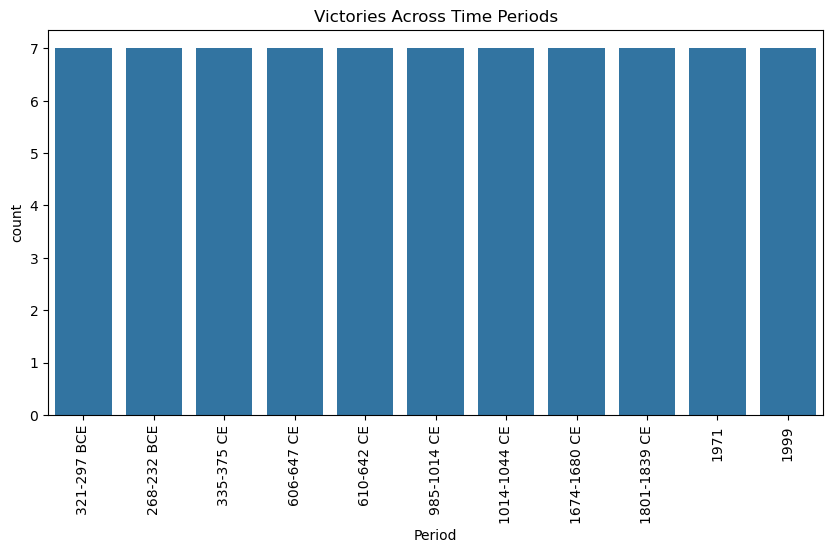

In [34]:

plt.figure(figsize=(10,5))

sns.countplot(x="Period", data=victories)

plt.xticks(rotation=90)
plt.title("Victories Across Time Periods")
plt.show()

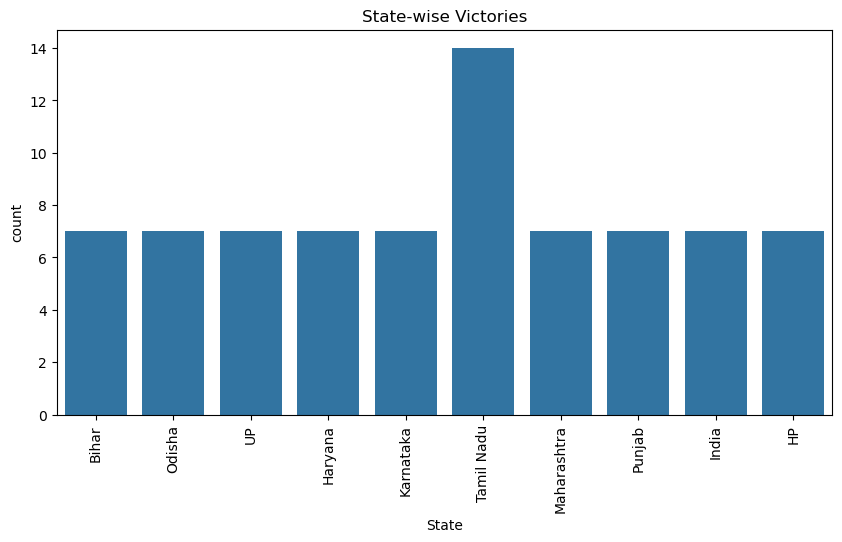

In [35]:
plt.figure(figsize=(10,5))

sns.countplot(x="State", data=victories)

plt.xticks(rotation=90)
plt.title("State-wise Victories")
plt.show()

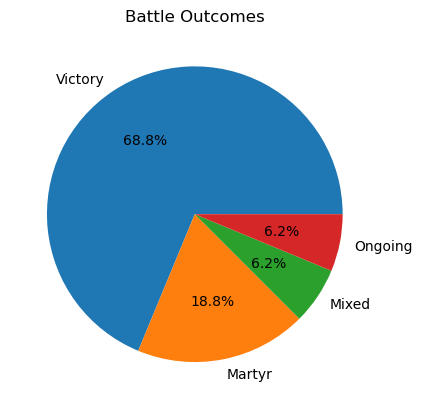

In [36]:
df["Outcome"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Battle Outcomes")
plt.ylabel("")
plt.show()

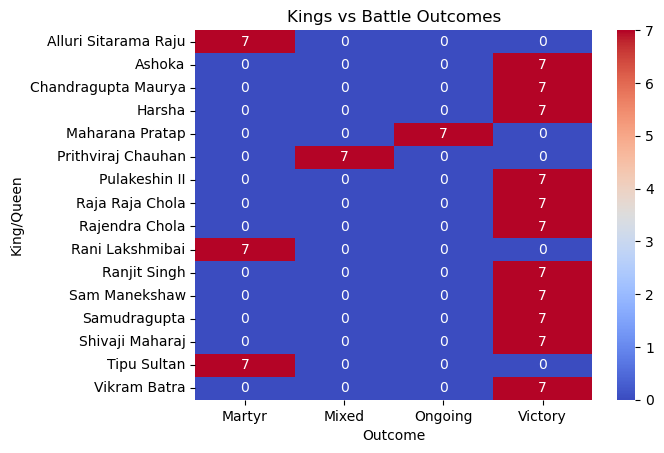

In [37]:
cross_tab = pd.crosstab(
    df["King/Queen"],
    df["Outcome"]
)

sns.heatmap(cross_tab, cmap="coolwarm", annot=True)

plt.title("Kings vs Battle Outcomes")
plt.show()

In [38]:
import pandas as pd
import re

def calculate_years(period):
    
    # extract all numbers
    years = re.findall(r'\d+', str(period))
    
    # case: 321-297 BCE
    if len(years) == 2:
        return abs(int(years[0]) - int(years[1]))
    
    # case: 1920s
    elif "s" in str(period):
        return 10
    
    # case: single year like 1971
    elif len(years) == 1:
        return 1
    
    else:
        return None

df["Years_of_Service"] = df["Period"].apply(calculate_years)

print(df[["Period", "Years_of_Service"]])

           Period  Years_of_Service
0     321-297 BCE                24
1     268-232 BCE                36
2      335-375 CE                40
3      606-647 CE                41
4      610-642 CE                32
..            ...               ...
107  1782-1799 CE                17
108  1801-1839 CE                38
109         1920s                10
110          1971                 1
111          1999                 1

[112 rows x 2 columns]


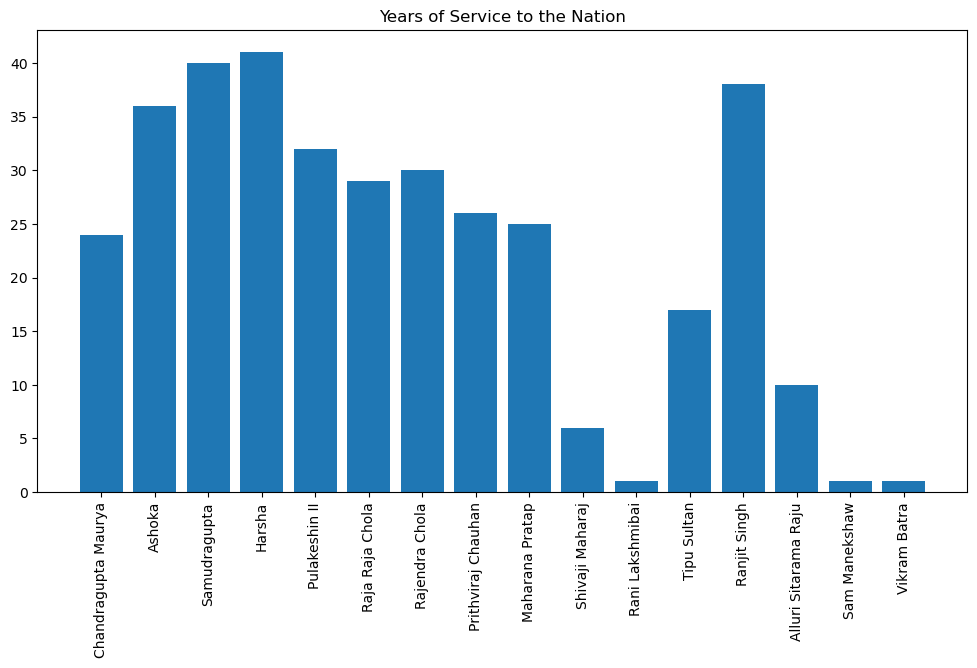

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    df["King/Queen"],
    df["Years_of_Service"]
)

plt.xticks(rotation=90)

plt.title("Years of Service to the Nation")

plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# encode categorical columns
le = LabelEncoder()
df["State"] = le.fit_transform(df["State"])
df["Outcome"] = le.fit_transform(df["Outcome"])
# features
X = df[["State", "Outcome"]]
# target
y = df["Estimated_Casualties"]
# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# model
model = RandomForestRegressor()
model.fit(X_train, y_train)
# prediction
predictions = model.predict(X_test)

print(predictions)

[11219.97091814  7326.37894261  9162.23664286  9005.77367063
 19425.81894841  8859.54670349 19425.81894841 18146.39834524
 19425.81894841  9657.5954026  10124.96727381 11214.55667968
  9162.23664286  7326.37894261  5244.13553968  9415.84078788
  8859.54670349  5244.13553968 11214.55667968 18146.39834524
  9162.23664286  9657.5954026   9005.77367063]


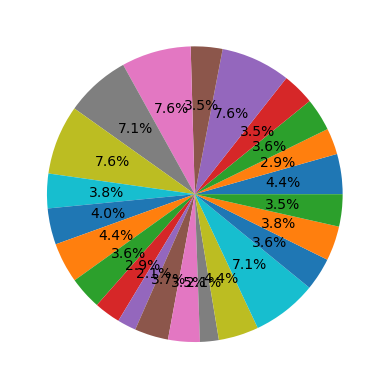

In [41]:
import matplotlib.pyplot as plt

plt.pie(predictions, autopct='%1.1f%%')

plt.show()

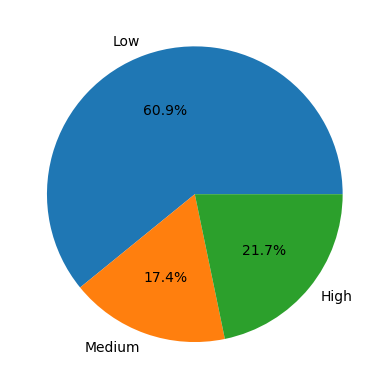

In [42]:
import pandas as pd

# Convert predictions into groups
groups = pd.cut(predictions, bins=3, labels=["Low", "Medium", "High"])

# Count groups
values = groups.value_counts()

# Pie chart
plt.pie(values, labels=values.index, autopct='%1.1f%%')

plt.show()